In [ ]:
# Importando as bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
dados=pd.read_csv('/content/multas_pagas.csv')

In [ ]:
dados.head()

,ID_MUNICIPIO,MUNICIPIO,CODIGO_INFRACAO,DESCRICAO_INFRACAO,UF_PLACA_VEICULO,TIPO_VEICULO,CATEGORIA_VEICULO,QTDE,MES,ANO
0,6789,OSASCO,7684-2,Cond motoc/moton/ciclom c/ util cap de seg c/ ...,SP,MOTOCICLO,PARTICULAR,30,7,2026
1,6181,ATIBAIA,7633-2,Dirigir veiculo manuseando telefone celular,SP,AUTOMOVEL,PARTICULAR,20,7,2026
2,7097,SAO JOSE DO RIO PRETO,7544-1,Falta de escrituracao livro registro entrada/s...,SP,AUTOMOVEL,PARTICULAR,19,7,2026
3,6425,FRANCA,6599-2,Conduzir o veiculo registrado que nao esteja d...,SP,AUTOMOVEL,PARTICULAR,77,7,2026
4,6673,MANDURI,5185-1,Deixar o condutor de usar o cinto seguranca,SP,CAMIONETA,PARTICULAR,1,7,2026


In [ ]:
# Conhecendo o dados
dados.shape
print(f"Quantidade de linhas: {dados.shape[0]}")
print(f"Quantidade de colunas: {dados.shape[1]}")

Quantidade de linhas: 24849
Quantidade de colunas: 10


In [ ]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24849 entries, 0 to 24848
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   ID_MUNICIPIO        24849 non-null  int64 
 1   MUNICIPIO           24849 non-null  object
 2   CODIGO_INFRACAO     24849 non-null  object
 3   DESCRICAO_INFRACAO  24849 non-null  object
 4   UF_PLACA_VEICULO    24849 non-null  object
 5   TIPO_VEICULO        24695 non-null  object
 6   CATEGORIA_VEICULO   24502 non-null  object
 7   QTDE                24849 non-null  int64 
 8   MES                 24849 non-null  int64 
 9   ANO                 24849 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 1.9+ MB


In [ ]:
# Verificando dados ausentes(null)
dados.isnull().sum()

,0
ID_MUNICIPIO,0
MUNICIPIO,0
CODIGO_INFRACAO,0
DESCRICAO_INFRACAO,0
UF_PLACA_VEICULO,0
TIPO_VEICULO,154
CATEGORIA_VEICULO,347
QTDE,0
MES,0
ANO,0


In [ ]:
nulos=dados.isnull().sum()
percentual_nulos=(
    dados.isnull().sum()/len(dados)*100
)
analise_nulos=pd.DataFrame({
    "quantidade_nulos":nulos,
    "percentual_nulos":percentual_nulos
})
analise_nulos.sort_values(by="percentual_nulos",ascending=False)

,quantidade_nulos,percentual_nulos
CATEGORIA_VEICULO,347,1.396434
TIPO_VEICULO,154,0.619743
MUNICIPIO,0,0.000000
ID_MUNICIPIO,0,0.000000
DESCRICAO_INFRACAO,0,0.000000
CODIGO_INFRACAO,0,0.000000
UF_PLACA_VEICULO,0,0.000000
QTDE,0,0.000000
MES,0,0.000000
ANO,0,0.000000


In [ ]:
# Tratando os valores ausentes
# Substituindo os valores nulos

dados['TIPO_VEICULO']=dados['TIPO_VEICULO'].fillna('Não informado')
dados['CATEGORIA_VEICULO']=dados['CATEGORIA_VEICULO'].fillna('Não informado')


In [ ]:
dados.isnull().sum()

,0
ID_MUNICIPIO,0
MUNICIPIO,0
CODIGO_INFRACAO,0
DESCRICAO_INFRACAO,0
UF_PLACA_VEICULO,0
TIPO_VEICULO,0
CATEGORIA_VEICULO,0
QTDE,0
MES,0
ANO,0


In [ ]:
# Procurando valores Duplicados
dados.duplicated().sum()

np.int64(0)

In [ ]:
# Verificando os tipos de dados
dados.dtypes

,0
ID_MUNICIPIO,int64
MUNICIPIO,object
CODIGO_INFRACAO,object
DESCRICAO_INFRACAO,object
UF_PLACA_VEICULO,object
TIPO_VEICULO,object
CATEGORIA_VEICULO,object
QTDE,int64
MES,int64
ANO,int64


In [ ]:
dados.describe()

,ID_MUNICIPIO,QTDE,MES,ANO
count,24849.000000,24849.000000,24849.0,24849.0
mean,6592.556119,8.396917,7.0,2026.0
std,765.223420,307.860034,0.0,0.0
min,790.000000,1.000000,7.0,2026.0
25%,6377.000000,1.000000,7.0,2026.0
50%,6687.000000,1.000000,7.0,2026.0
75%,7057.000000,2.000000,7.0,2026.0
max,7273.000000,44554.000000,7.0,2026.0


In [ ]:
dados['QTDE'].describe()

,QTDE
count,24849.000000
mean,8.396917
std,307.860034
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,44554.000000


In [ ]:
# Verificando a quantidade total de multas
total_multas=dados['QTDE'].sum()
print(f"Quantidade total de multas: {total_multas}")

Quantidade total de multas: 208655


In [ ]:
# Quantidade de municipios presente na base de dados
Total_municipios=dados['MUNICIPIO'].nunique()
print(f"Quantidade de municipios: {Total_municipios}")

Quantidade de municipios: 625


In [ ]:
#Quantidade de tipos de infraçoes
Total_infracoes=dados['DESCRICAO_INFRACAO'].nunique()
print(f"Quantidade de infrações: {Total_infracoes}")

Quantidade de infrações: 313


In [ ]:
#Resumos dos dados
print("Resumo da base de dados")
print("-"*50)
print(f"Total de ocorrencia: {dados['QTDE'].sum()}")
print(f"Total de infracoes: {dados['DESCRICAO_INFRACAO'].nunique()}")
print(f"Total de municipios: {dados['MUNICIPIO'].nunique()}")
print(f"tipos de veiculos: {dados['TIPO_VEICULO'].nunique()}")
print(f"Categorias de veiculos: {dados['CATEGORIA_VEICULO'].nunique()}")

Resumo da base de dados
--------------------------------------------------
Total de ocorrencia: 208655
Total de infracoes: 313
Total de municipios: 625
tipos de veiculos: 17
Categorias de veiculos: 6


In [ ]:
#Municipios com mais multas
multas_municipios=(
    dados.groupby('MUNICIPIO')['QTDE']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
multas_municipios.head(10)

,MUNICIPIO,QTDE
0,SAO PAULO,146526
1,GUARULHOS,2799
2,SOROCABA,2204
3,CARAPICUIBA,1610
4,JUNDIAI,1403
5,DIADEMA,1398
6,RIBEIRAO PRETO,1381
7,CAMPINAS,1371
8,BAURU,1246
9,SAO BERNARDO DO CAMPO,1175


In [ ]:
# calculando a porcentagem de ocorrencias em São paulo
Partipacao_sp=(
    multas_municipios.loc[multas_municipios['MUNICIPIO']=='SAO PAULO','QTDE']
    .iloc[0]
    /dados['QTDE'].sum()
    *100
)
print(f"A porcentagem de ocorrencias em São Paulo é: {Partipacao_sp:.2f}%")

A porcentagem de ocorrencias em São Paulo é: 70.22%


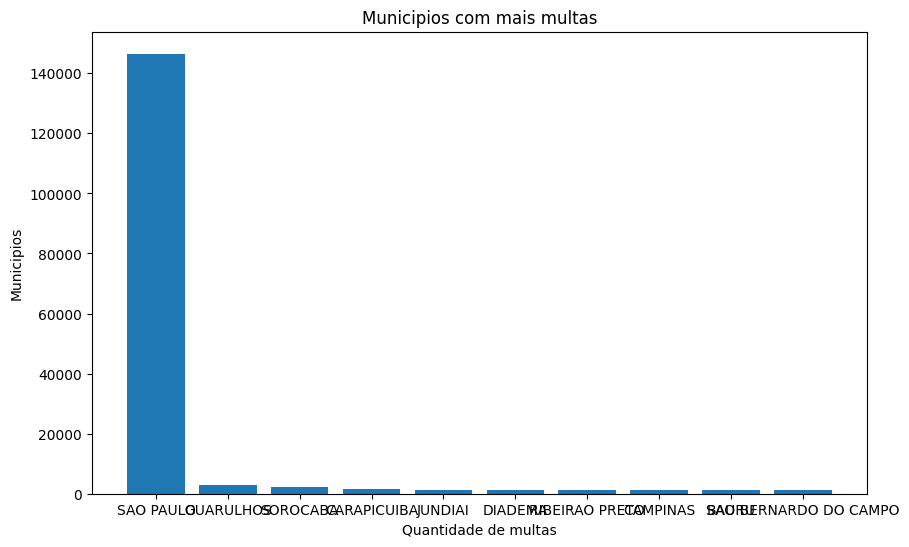

In [ ]:
top_municipios=multas_municipios.head(10)
plt.figure(figsize=(10,6))
plt.bar(
    top_municipios['MUNICIPIO'],
    top_municipios['QTDE'])
plt.title('Municipios com mais multas')
plt.xlabel('Quantidade de multas')
plt.ylabel('Municipios')

plt.show()


In [ ]:
# Infraçoes mais frequentes
infracoes_mais_frequentes=(
    dados.groupby('DESCRICAO_INFRACAO')['QTDE']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
infracoes_mais_frequentes.head(10)

,DESCRICAO_INFRACAO,QTDE
0,Deixar de efetuar registro do veiculo em 30 di...,80016
1,Conduzir o veiculo registrado que nao esteja d...,18413
2,Dirigir veiculo manuseando telefone celular,11647
3,Deixar o condutor de usar o cinto seguranca,11315
4,Avancar o sinal vermelho do semaforo,5834
5,"Multa, por nao identificacao do condutor infra...",5039
6,Dirigir veiculo sem possuir CNH ou Permissao p...,4281
7,Cond motoc/moton/ciclom c/ util cap de seg c/ ...,4240
8,Conduzir o veiculo em mau estado de conservacao,3890
9,Dirigir o veic usando calcado que n se firme n...,3796


In [ ]:
# percentual das infraçoes
infracoes_mais_frequentes['PERCENTUAL']=(
    infracoes_mais_frequentes['QTDE']/
    infracoes_mais_frequentes['QTDE'].sum()*100
)
infracoes_mais_frequentes.head(10)

,DESCRICAO_INFRACAO,QTDE,PERCENTUAL
0,Deixar de efetuar registro do veiculo em 30 di...,80016,38.348470
1,Conduzir o veiculo registrado que nao esteja d...,18413,8.824615
2,Dirigir veiculo manuseando telefone celular,11647,5.581941
3,Deixar o condutor de usar o cinto seguranca,11315,5.422827
4,Avancar o sinal vermelho do semaforo,5834,2.796003
5,"Multa, por nao identificacao do condutor infra...",5039,2.414991
6,Dirigir veiculo sem possuir CNH ou Permissao p...,4281,2.051712
7,Cond motoc/moton/ciclom c/ util cap de seg c/ ...,4240,2.032062
8,Conduzir o veiculo em mau estado de conservacao,3890,1.864321
9,Dirigir o veic usando calcado que n se firme n...,3796,1.819271


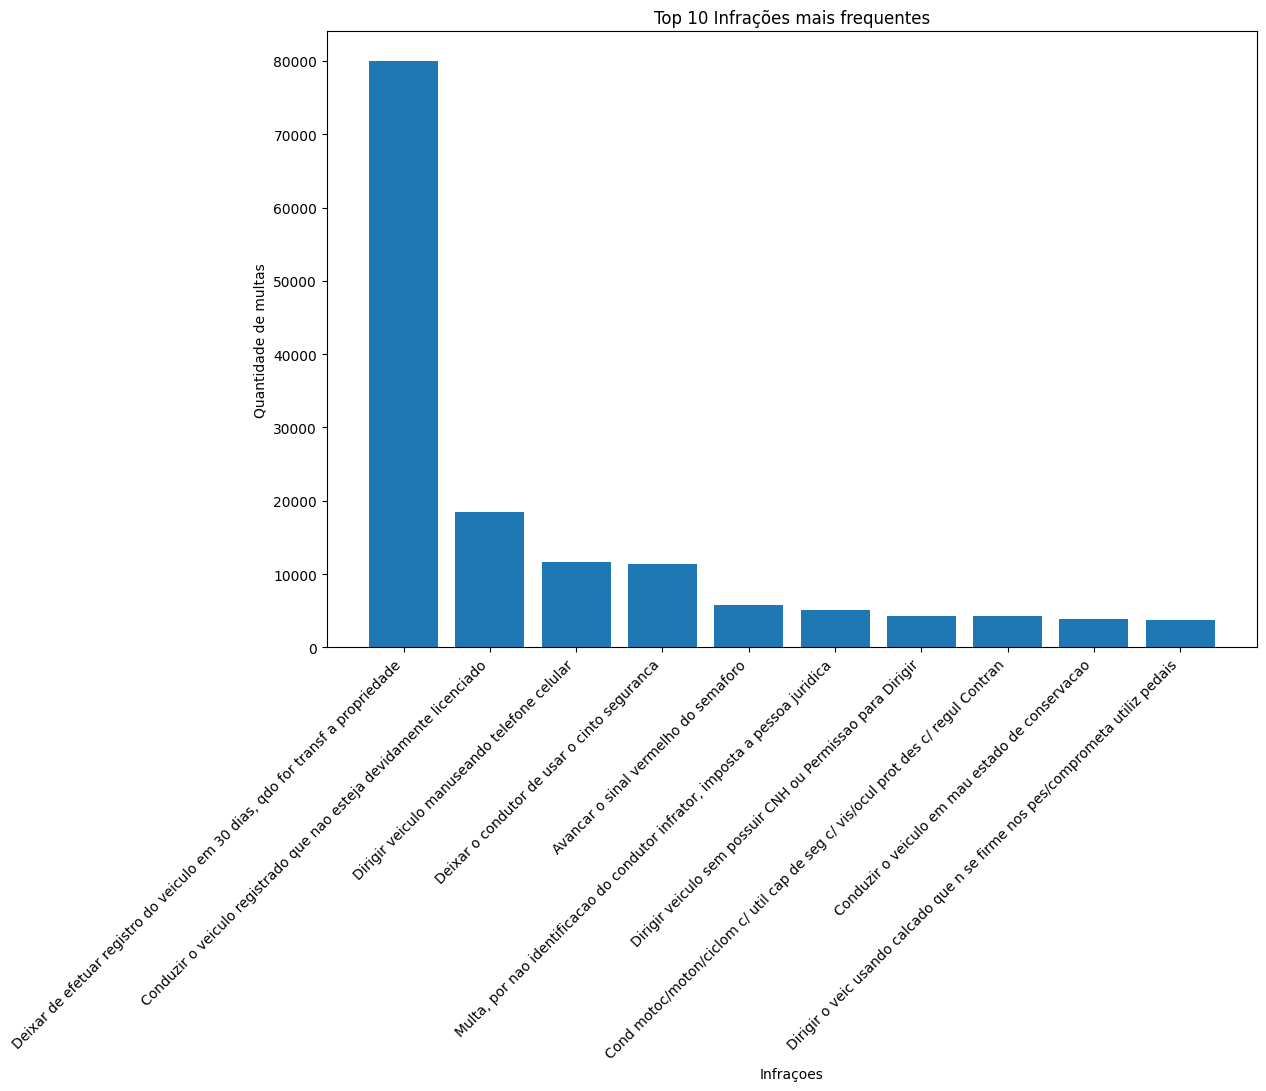

In [ ]:
top_infracoes=infracoes_mais_frequentes.head(10)
plt.figure(figsize=(12,8))
plt.bar(
    top_infracoes['DESCRICAO_INFRACAO'],
    top_infracoes['QTDE'])
plt.title('Top 10 Infrações mais frequentes')
plt.xlabel('Infraçoes')
plt.ylabel('Quantidade de multas')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability

plt.show()

In [ ]:
#Analise por tipo de veiculo
tipo_veiculo=(
    dados.groupby('TIPO_VEICULO')['QTDE']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
tipo_veiculo.head(10)


,TIPO_VEICULO,QTDE
0,AUTOMOVEL,109511
1,MOTOCICLO,48899
2,CAMINHONET,18302
3,CAMIONETA,10584
4,MOTONETA,7520
5,UTILITARIO,5423
6,CAMINHAO,2893
7,Não informado,1674
8,S. REBOQUE,865
9,C. TRATOR,861


In [ ]:
#Percentual de veiculos
tipo_veiculo['PERCENTUAL']=(
    tipo_veiculo['QTDE']/
    tipo_veiculo['QTDE'].sum()*100
)
tipo_veiculo.head(10)

,TIPO_VEICULO,QTDE,PERCENTUAL
0,AUTOMOVEL,109511,52.484244
1,MOTOCICLO,48899,23.435336
2,CAMINHONET,18302,8.771417
3,CAMIONETA,10584,5.072488
4,MOTONETA,7520,3.604035
5,UTILITARIO,5423,2.599027
6,CAMINHAO,2893,1.386499
7,Não informado,1674,0.802281
8,S. REBOQUE,865,0.414560
9,C. TRATOR,861,0.412643


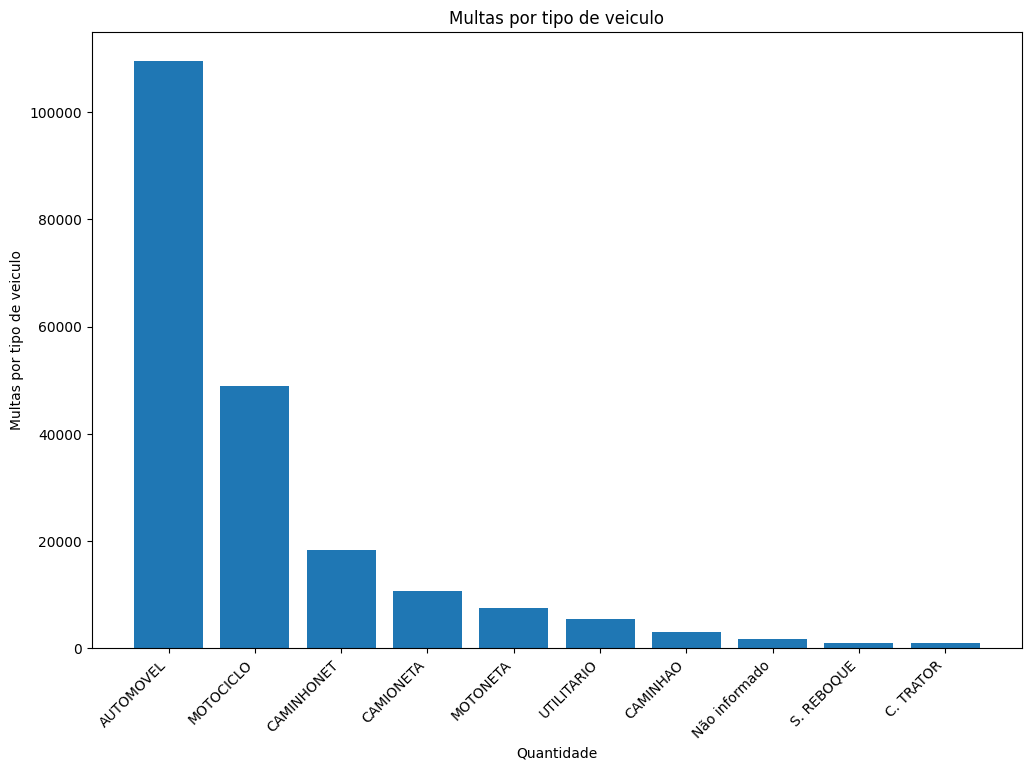

In [ ]:
#Grafico  por tipo de veiculos
top10_veiculos=tipo_veiculo.head(10)
plt.figure(figsize=(12,8))
plt.bar(
    top10_veiculos['TIPO_VEICULO'],
    top10_veiculos['QTDE'])

plt.title("Multas por tipo de veiculo")
plt.xlabel('Quantidade')
plt.ylabel('Multas por tipo de veiculo')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability

plt.show()

In [ ]:
#Categoria dos veiculos
categoria=(
    dados.groupby('CATEGORIA_VEICULO')['QTDE']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
categoria.head(10)


,CATEGORIA_VEICULO,QTDE
0,PARTICULAR,201713
1,ALUGUEL,6108
2,Não informado,499
3,APRENDIZAGEM,169
4,OFICIAL,165
5,C. CONSULAR,1


In [ ]:
#porcentual por categoria de veiculo
categoria['PERCENTUAL']=(
    categoria['QTDE']/
    categoria['QTDE'].sum()*100
)
categoria.head()

,CATEGORIA_VEICULO,QTDE,PERCENTUAL
0,PARTICULAR,201713,96.672977
1,ALUGUEL,6108,2.927320
2,Não informado,499,0.239151
3,APRENDIZAGEM,169,0.080995
4,OFICIAL,165,0.079078


In [ ]:
# Veiculos de SP x Outros estados
uf_veiculo=(
    dados.groupby('UF_PLACA_VEICULO')['QTDE']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
uf_veiculo


,UF_PLACA_VEICULO,QTDE
0,SP,199163
1,Outras UFs,9492


In [ ]:
uf_veiculo['PERCENTUAL']=(
    uf_veiculo['QTDE']/
    uf_veiculo['QTDE'].sum()*100
)
uf_veiculo


,UF_PLACA_VEICULO,QTDE,PERCENTUAL
0,SP,199163,95.450864
1,Outras UFs,9492,4.549136


Text(0, 0.5, 'Quantidade')

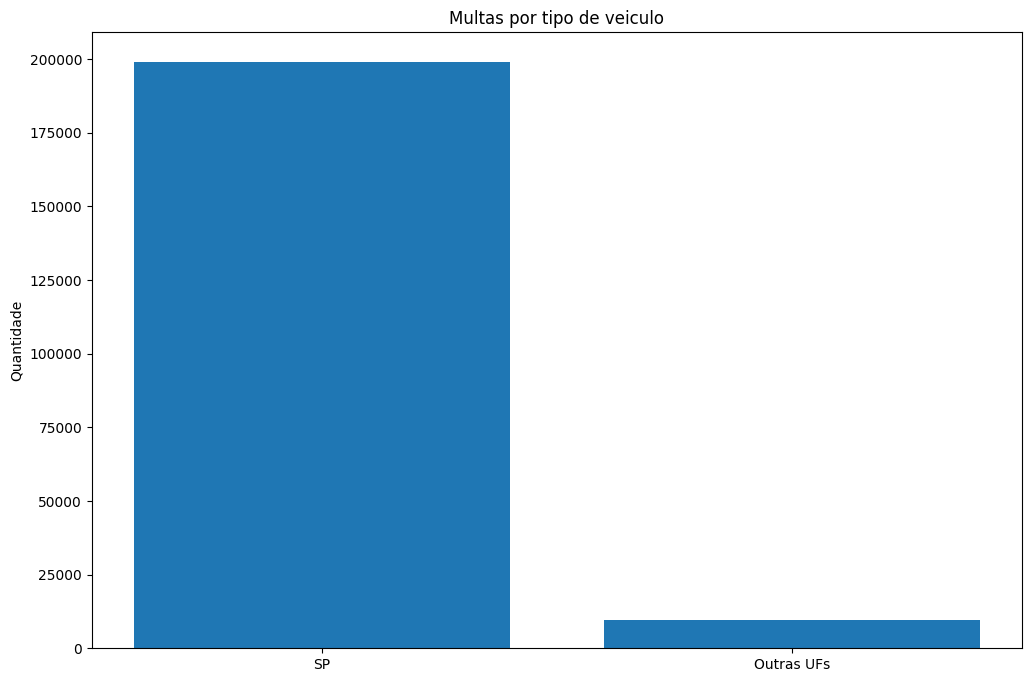

In [ ]:
#Grafico SP x Outros Ufs

plt.figure(figsize=(12,8))
plt.bar(
    uf_veiculo['UF_PLACA_VEICULO'],
    uf_veiculo['QTDE'])
plt.title("Multas por tipo de veiculo")
plt.ylabel('Quantidade')


In [ ]:
#Infraçoes mais comuns por tipo de veiculo

infracoes_mais_frequentes_por_tipo_veiculo=(
    dados.groupby([
        'TIPO_VEICULO','DESCRICAO_INFRACAO'
        ])['QTDE']
    .sum()
    .reset_index()
)
infracoes_mais_frequentes_por_tipo_veiculo.head()

,TIPO_VEICULO,DESCRICAO_INFRACAO,QTDE
0,AUTOMOVEL,Abandonar na via objetos ou substancias,5
1,AUTOMOVEL,Atirar do veiculo objetos ou substancias,61
2,AUTOMOVEL,Avancar o sinal de parada obrigatoria,473
3,AUTOMOVEL,Avancar o sinal vermelho do semaforo,2847
4,AUTOMOVEL,Avancar o sinal vermelho do semaforo - fiscali...,104


In [ ]:
motos=(
    infracoes_mais_frequentes_por_tipo_veiculo[
        infracoes_mais_frequentes_por_tipo_veiculo['TIPO_VEICULO']=='MOTOCICLO'
    ]
    .sort_values(by='QTDE',ascending=False)

)
motos.head()

,TIPO_VEICULO,DESCRICAO_INFRACAO,QTDE
929,MOTOCICLO,Deixar de efetuar registro do veiculo em 30 di...,12951
868,MOTOCICLO,Cond motoc/moton/ciclom c/ util cap de seg c/ ...,3593
952,MOTOCICLO,Dirigir o veic usando calcado que n se firme n...,3149
906,MOTOCICLO,Conduzir o veiculo registrado que nao esteja d...,2838
970,MOTOCICLO,Dirigir veiculo sem possuir CNH ou Permissao p...,2172


In [ ]:
automoveis=(
    infracoes_mais_frequentes_por_tipo_veiculo[
        infracoes_mais_frequentes_por_tipo_veiculo['TIPO_VEICULO']=='AUTOMOVEL'
    ]
    .sort_values(by='QTDE',ascending=False)

)
automoveis.head(10)


,TIPO_VEICULO,DESCRICAO_INFRACAO,QTDE
62,AUTOMOVEL,Deixar de efetuar registro do veiculo em 30 di...,46128
29,AUTOMOVEL,Conduzir o veiculo registrado que nao esteja d...,11771
85,AUTOMOVEL,Deixar o condutor de usar o cinto seguranca,8796
105,AUTOMOVEL,Dirigir veiculo manuseando telefone celular,7783
3,AUTOMOVEL,Avancar o sinal vermelho do semaforo,2847
35,AUTOMOVEL,Conduzir veic.c/ defeito no sist.de iluminacao...,2683
8,AUTOMOVEL,Cond que se recusar a se submeter a qq dos pro...,2288
170,AUTOMOVEL,"Multa, por nao identificacao do condutor infra...",2246
27,AUTOMOVEL,Conduzir o veiculo em mau estado de conservacao,1495
107,AUTOMOVEL,Dirigir veiculo segurando telefone celular,1491


In [ ]:
#Analisando Sao Paulo separadamente
sp=dados[dados['MUNICIPIO']=='SAO PAULO']
sp.shape

sp['QTDE'].sum()

np.int64(146526)

In [ ]:
#Principais infraçoes
(
    sp.groupby('DESCRICAO_INFRACAO')['QTDE']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
    .head(10)
)

,DESCRICAO_INFRACAO,QTDE
0,Deixar de efetuar registro do veiculo em 30 di...,79047
1,Conduzir o veiculo registrado que nao esteja d...,11886
2,Dirigir veiculo manuseando telefone celular,7865
3,"Multa, por nao identificacao do condutor infra...",5039
4,Deixar o condutor de usar o cinto seguranca,4661
5,Avancar o sinal vermelho do semaforo,3603
6,Conduzir veic.c/ defeito no sist.de iluminacao...,3151
7,Cond motoc/moton/ciclom c/ util cap de seg c/ ...,2166
8,Cond que se recusar a se submeter a qq dos pro...,1706
9,Dirigir veiculo sem possuir CNH ou Permissao p...,1510


In [ ]:
#Analisando sem SP
sem_sp=dados[dados['MUNICIPIO']!='SAO PAULO']
sem_sp.shape

(22997, 10)

In [ ]:
(
    sem_sp.groupby('DESCRICAO_INFRACAO')['QTDE']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
    .head(10)
)
sem_sp

,ID_MUNICIPIO,MUNICIPIO,CODIGO_INFRACAO,DESCRICAO_INFRACAO,UF_PLACA_VEICULO,TIPO_VEICULO,CATEGORIA_VEICULO,QTDE,MES,ANO
0,6789,OSASCO,7684-2,Cond motoc/moton/ciclom c/ util cap de seg c/ ...,SP,MOTOCICLO,PARTICULAR,30,7,2026
1,6181,ATIBAIA,7633-2,Dirigir veiculo manuseando telefone celular,SP,AUTOMOVEL,PARTICULAR,20,7,2026
2,7097,SAO JOSE DO RIO PRETO,7544-1,Falta de escrituracao livro registro entrada/s...,SP,AUTOMOVEL,PARTICULAR,19,7,2026
3,6425,FRANCA,6599-2,Conduzir o veiculo registrado que nao esteja d...,SP,AUTOMOVEL,PARTICULAR,77,7,2026
4,6673,MANDURI,5185-1,Deixar o condutor de usar o cinto seguranca,SP,CAMIONETA,PARTICULAR,1,7,2026
...,...,...,...,...,...,...,...,...,...,...
24844,6779,OLIMPIA,6637-1,Conduzir o veiculo sem equipamento obrigatorio,SP,MOTOCICLO,PARTICULAR,1,7,2026
24845,6543,ITANHAEM,5185-1,Deixar o condutor de usar o cinto seguranca,SP,CAMINHONET,ALUGUEL,1,7,2026
24846,6875,PIRACICABA,7579-0,Cond que se recusar a se submeter a qq dos pro...,SP,UTILITARIO,PARTICULAR,1,7,2026
24847,6183,AURIFLAMA,6599-2,Conduzir o veiculo registrado que nao esteja d...,SP,AUTOMOVEL,PARTICULAR,1,7,2026


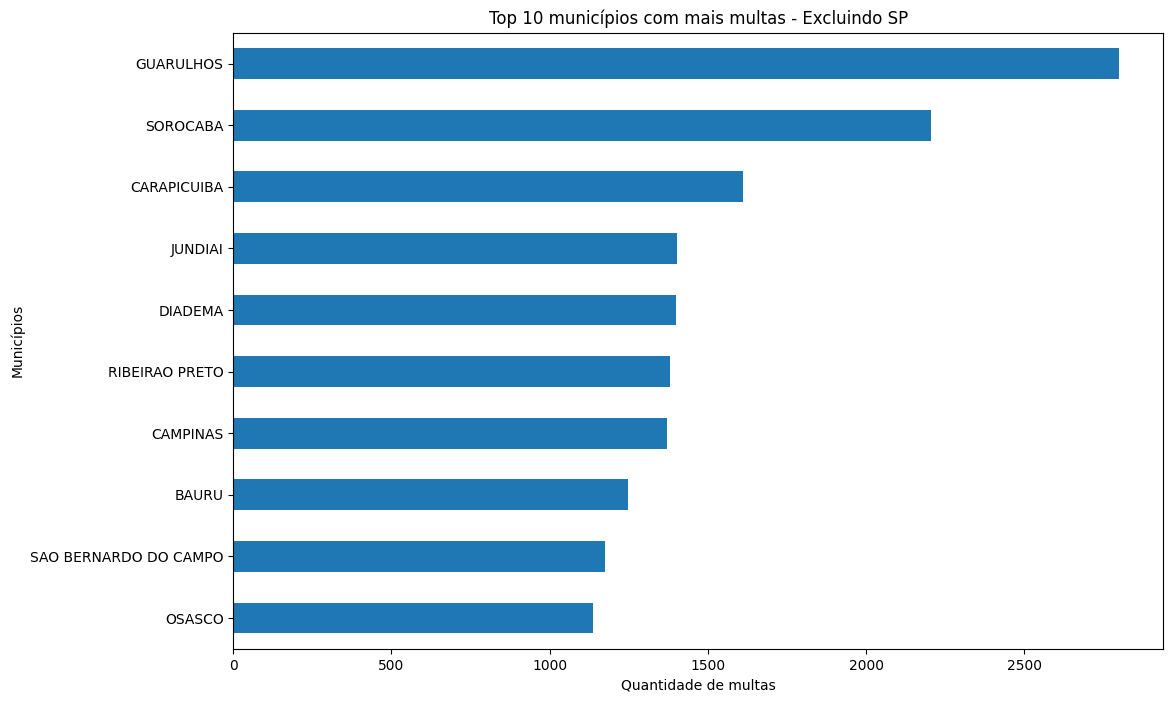

In [ ]:
plt.figure(figsize=(12,8))

# Agrupar por município, somar as multas, ordenar e pegar os top 10
top10_municipios_sem_sp = sem_sp.groupby('MUNICIPIO')['QTDE']\
                                  .sum()\
                                  .sort_values(ascending=False)\
                                  .head(10)

top10_municipios_sem_sp.plot(
    kind="barh"
)
plt.title("Top 10 municípios com mais multas - Excluindo SP")
plt.xlabel("Quantidade de multas")
plt.ylabel("Municípios")
plt.gca().invert_yaxis() # Inverte o eixo Y para o maior estar no topo
plt.show()

In [ ]:
# Identificando Concentraçoes das Infraçoes
top10_total=infracoes_mais_frequentes.head(10)['QTDE'].sum()

porcentual_top10=(
    top10_total/
    dados['QTDE'].sum()
    *100
)
print(f"O top 10 representa {porcentual_top10:.2f}% das multas")

O top 10 representa 71.16% das multas


In [ ]:
# Analise de pareto

pareto=infracoes_mais_frequentes.copy()
pareto['PERCENTUAL']=(
  pareto['QTDE']/
  pareto['QTDE'].sum()*100
)
pareto['PERCENTUAL_ACUMULADO']=pareto['PERCENTUAL'].cumsum()
pareto.head(20)


,DESCRICAO_INFRACAO,QTDE,PERCENTUAL,PERCENTUAL_ACUMULADO
0,Deixar de efetuar registro do veiculo em 30 di...,80016,38.348470,38.348470
1,Conduzir o veiculo registrado que nao esteja d...,18413,8.824615,47.173085
2,Dirigir veiculo manuseando telefone celular,11647,5.581941,52.755026
3,Deixar o condutor de usar o cinto seguranca,11315,5.422827,58.177853
4,Avancar o sinal vermelho do semaforo,5834,2.796003,60.973856
5,"Multa, por nao identificacao do condutor infra...",5039,2.414991,63.388848
6,Dirigir veiculo sem possuir CNH ou Permissao p...,4281,2.051712,65.440560
7,Cond motoc/moton/ciclom c/ util cap de seg c/ ...,4240,2.032062,67.472622
8,Conduzir o veiculo em mau estado de conservacao,3890,1.864321,69.336944
9,Dirigir o veic usando calcado que n se firme n...,3796,1.819271,71.156215


In [ ]:
# Infraçoes responsaveis por 80% das ocorrencias
pareto[pareto['PERCENTUAL_ACUMULADO']<80]

,DESCRICAO_INFRACAO,QTDE,PERCENTUAL,PERCENTUAL_ACUMULADO
0,Deixar de efetuar registro do veiculo em 30 di...,80016,38.348470,38.348470
1,Conduzir o veiculo registrado que nao esteja d...,18413,8.824615,47.173085
2,Dirigir veiculo manuseando telefone celular,11647,5.581941,52.755026
3,Deixar o condutor de usar o cinto seguranca,11315,5.422827,58.177853
4,Avancar o sinal vermelho do semaforo,5834,2.796003,60.973856
5,"Multa, por nao identificacao do condutor infra...",5039,2.414991,63.388848
6,Dirigir veiculo sem possuir CNH ou Permissao p...,4281,2.051712,65.440560
7,Cond motoc/moton/ciclom c/ util cap de seg c/ ...,4240,2.032062,67.472622
8,Conduzir o veiculo em mau estado de conservacao,3890,1.864321,69.336944
9,Dirigir o veic usando calcado que n se firme n...,3796,1.819271,71.156215


In [ ]:
# Ranking com posição
multas_municipios['RANKING']=(
    multas_municipios['QTDE']
    .rank(method='dense',ascending=False)
    .astype(int)
)
multas_municipios.head(10)

,MUNICIPIO,QTDE,RANKING
0,SAO PAULO,146526,1
1,GUARULHOS,2799,2
2,SOROCABA,2204,3
3,CARAPICUIBA,1610,4
4,JUNDIAI,1403,5
5,DIADEMA,1398,6
6,RIBEIRAO PRETO,1381,7
7,CAMPINAS,1371,8
8,BAURU,1246,9
9,SAO BERNARDO DO CAMPO,1175,10


In [ ]:
indicadores = pd.DataFrame({
    'Indicador': [
        'Total de ocorrências',
        'Quantidade de municípios',
        'Tipos de infração',
        'Tipos de veículo'
    ],
    'Valor': [
        dados['QTDE'].sum(),
        dados['MUNICIPIO'].nunique(),
        dados['CODIGO_INFRACAO'].nunique(),
        dados['TIPO_VEICULO'].nunique()
    ]
})

indicadores

,Indicador,Valor
0,Total de ocorrências,208655
1,Quantidade de municípios,625
2,Tipos de infração,313
3,Tipos de veículo,17


In [ ]:
multas_municipios.to_csv(
    'ranking_municipios.csv',
    index=False
)

In [ ]:
with pd.ExcelWriter('analise_multas.xlsx') as writer:

    multas_municipios.to_excel(
        writer,
        sheet_name='Municipios',
        index=False
    )

    infracoes_mais_frequentes.to_excel(
        writer,
        sheet_name='Infracoes',
        index=False
    )

    tipo_veiculo.to_excel(
        writer,
        sheet_name='Veiculos',
        index=False
    )

    categoria.to_excel(
        writer,
        sheet_name='Categorias',
        index=False
    )